# TASK 5 - Neural network

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
) 
from sklearn.model_selection import GridSearchCV

# Load data
X_train = pd.read_csv('../data/2_processed/X_train.csv')
X_test  = pd.read_csv('../data/2_processed/X_test.csv')
y_train = pd.read_csv('../data/2_processed/y_train.csv')["target"]
y_test  = pd.read_csv('../data/2_processed/y_test.csv')["target"]

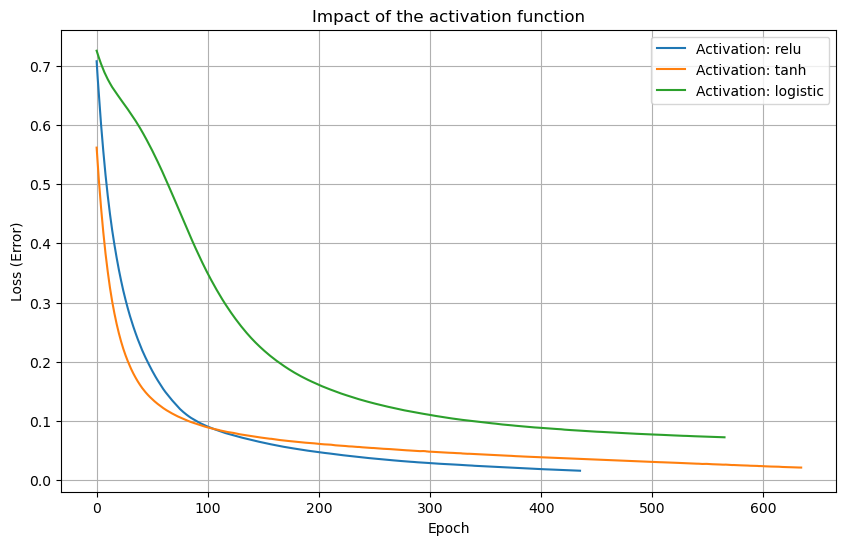

In [3]:
#Comparison of the different activation functions

activations = ['relu', 'tanh', 'logistic']
plt.figure(figsize=(10, 6))

for act in activations:
    mlp = MLPClassifier(
        hidden_layer_sizes=(16, 8), 
        activation=act,
        max_iter=1000, 
        random_state=42
    )
    mlp.fit(X_train, y_train)
    plt.plot(mlp.loss_curve_, label=f'Activation: {act}')

plt.title('Impact of the activation function')
plt.xlabel('Epoch')
plt.ylabel('Loss (Error)')
plt.legend()
plt.grid(True)
plt.show()

We can see Relu droping and stabilizing faster. For that reason we will use this activation function.

In [4]:
#  Different Alpha and Learning rate evaluation

# Searching space
param_grid = {
    'alpha': [0.0001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'hidden_layer_sizes': [(16, 8), (32, 16), (32,16,8), (32,32,32), (64,32,16),(64,32,16,8), (64,32,16,8,4)]
}

grid = GridSearchCV(
    MLPClassifier(activation='relu', max_iter=1000, early_stopping=True, random_state=42),
    param_grid, 
    cv=3, 
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)

Best parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (64, 32, 16, 8), 'learning_rate_init': 0.1}


C:\Users\paulo\AppData\Local\Temp\ipykernel_56212\1239126619.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='architecture', y='mean_test_score', palette='viridis')


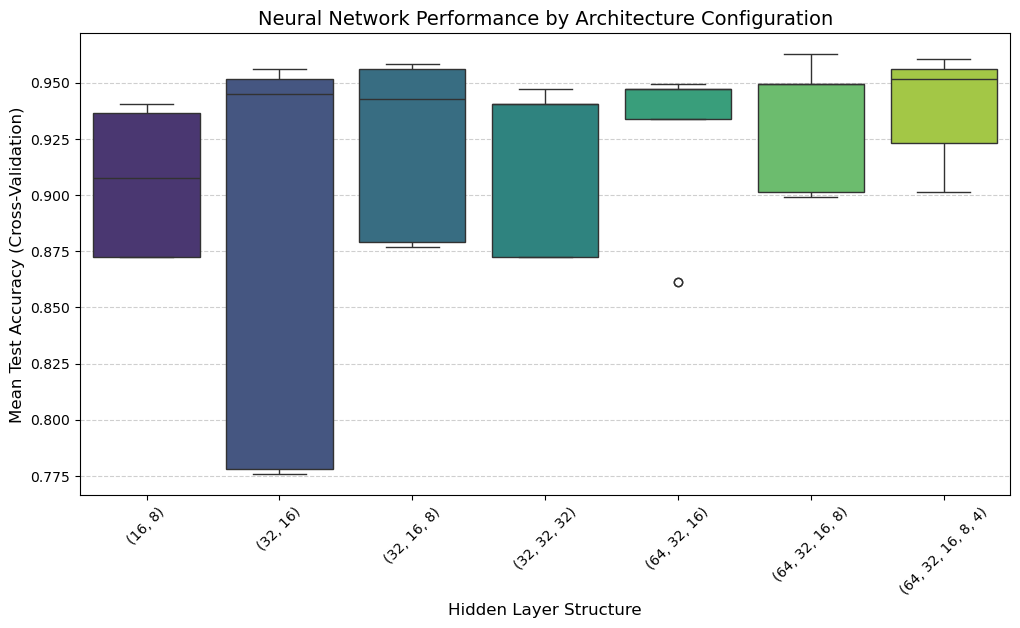

In [5]:
# Convert GridSearch results to a DataFrame
results_df = pd.DataFrame(grid.cv_results_)

# Convert architecture tuples to strings for better plot readability
results_df['architecture'] = results_df['param_hidden_layer_sizes'].astype(str)

# Create the visualization
plt.figure(figsize=(12, 6))

# Boxplot shows the distribution of scores for each architecture
sns.boxplot(data=results_df, x='architecture', y='mean_test_score', palette='viridis')


plt.title('Neural Network Performance by Architecture Configuration', fontsize=14)
plt.xlabel('Hidden Layer Structure', fontsize=12)
plt.ylabel('Mean Test Accuracy (Cross-Validation)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

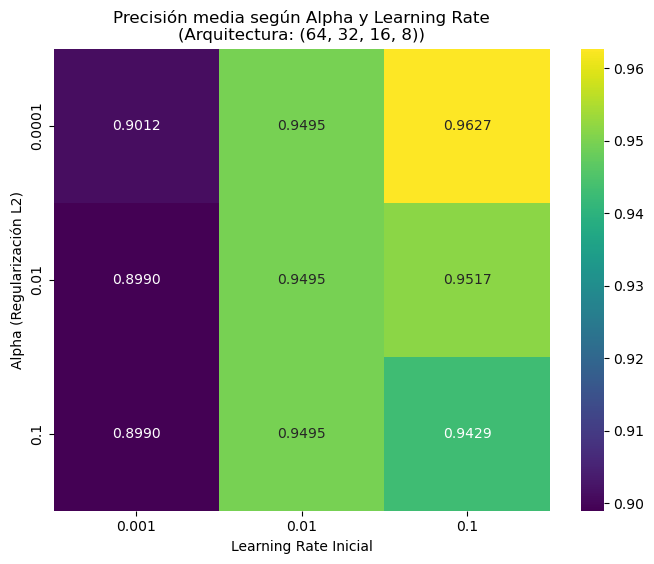

In [6]:
#Heatmap 

results_df = pd.DataFrame(grid.cv_results_)

best_arch = grid.best_params_['hidden_layer_sizes']
subset_results = results_df[results_df['param_hidden_layer_sizes'] == best_arch]


viz_data = subset_results.pivot(index='param_alpha', 
                                columns='param_learning_rate_init', 
                                values='mean_test_score')

plt.figure(figsize=(8, 6))
sns.heatmap(viz_data, annot=True, cmap='viridis', fmt='.4f')
plt.title(f'Precisión media según Alpha y Learning Rate\n(Arquitectura: {best_arch})')
plt.ylabel('Alpha (Regularización L2)')
plt.xlabel('Learning Rate Inicial')
plt.show()

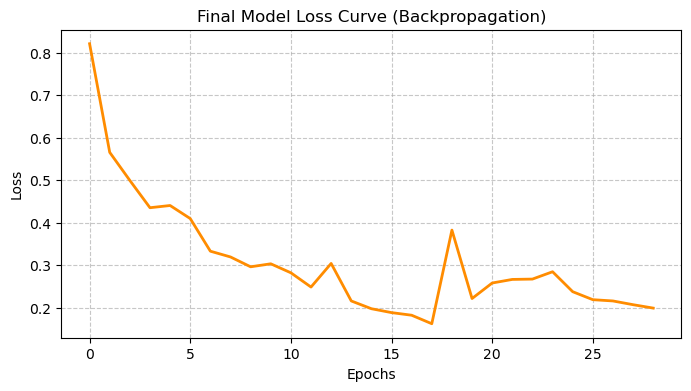

In [7]:
# Fit the model with the best parameters found
final_mlp = grid.best_estimator_

final_mlp.fit(X_train, y_train)

# Final loss curve visualization
plt.figure(figsize=(8, 4))
plt.plot(final_mlp.loss_curve_, color='darkorange', linewidth=2)
plt.title('Final Model Loss Curve (Backpropagation)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

--- FINAL PERFORMANCE REPORT ---
Test Accuracy: 0.9474
-----------------------------------
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        42
           1       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



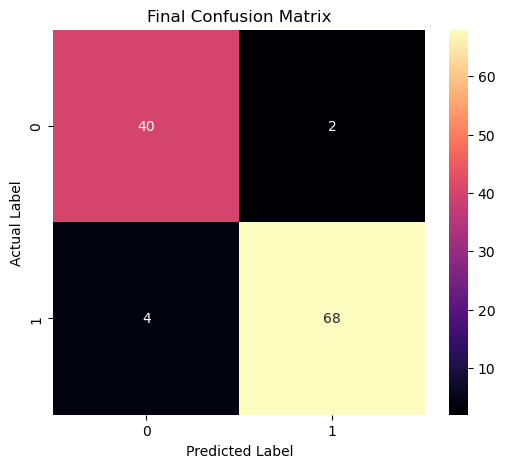

In [8]:
from sklearn.metrics import accuracy_score

# Final predictions using the best model
y_pred_final = final_mlp.predict(X_test)

print("--- FINAL PERFORMANCE REPORT ---")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print("-" * 35)
print(classification_report(y_test, y_pred_final))

# Professional Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='magma')
plt.title('Final Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

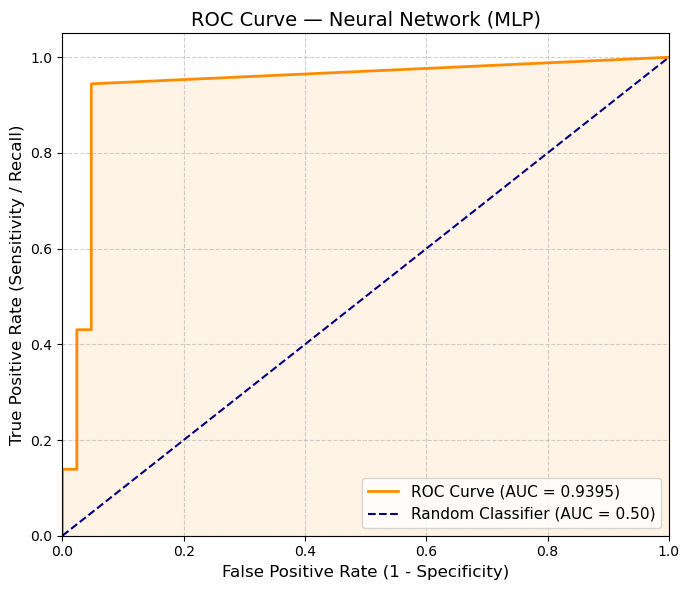

AUC Score: 0.9395


In [11]:
from sklearn.metrics import roc_curve, auc

# Get probability scores for the positive class
y_prob = final_mlp.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', linewidth=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linewidth=1.5,
         linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('ROC Curve — Neural Network (MLP)', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

In [12]:
import time

start = time.time()
final_mlp.fit(X_train, y_train)
end = time.time()

training_time = end - start
print(f"Training time: {training_time:.4f} seconds")

Training time: 0.0979 seconds
